### About the Project
This project builds a predictive model to help a company look for potential candidates from a pool of training program attendants by predicting whether or not the employee is looking for a job change. The features are as follows:

* enrollee_id : unique ID for candidate
* city_development_index : developement index of the city (scaled)
* gender: gender of candidate
* relevent_experience: relevant experience of candidate
* enrolled_university: type of university course enrolled if any
* education_level: education level of candidate
* major_discipline: education major discipline of candidate
* experience: candidate's total experience in years
* company_size: number of employees in the current company of candidate
* company_type : Type of current employer
* last_new_job: difference in years between previous job and current job
* training_hours: training hours completed
* target value: 0 – not looking for job change, 1 – looking for a job change


In [120]:
# Load Pandas library and load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("data-employee-recruitment.csv")

In [121]:
df.head(n = 10)

,enrollee_id,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,14569,0.704,Male,Has relevent experience,Full time course,Graduate,STEM,2,50-99,Pvt Ltd,2,71,1.0
1,10557,0.594,Female,Has relevent experience,Full time course,Masters,STEM,9,50-99,Early Stage Startup,never,217,1.0
2,14095,0.596,Male,Has relevent experience,Part time course,Graduate,Humanities,2,100-500,Pvt Ltd,2,12,1.0
3,16300,0.614,Male,Has relevent experience,Full time course,Masters,STEM,4,50-99,Pvt Ltd,1,20,1.0
4,14550,0.534,Male,No relevent experience,Full time course,Graduate,STEM,<1,50-99,Early Stage Startup,1,52,1.0
5,6607,0.704,Male,Has relevent experience,Full time course,Graduate,STEM,5,<10,Early Stage Startup,never,60,1.0
6,8143,0.724,Female,No relevent experience,Full time course,Graduate,STEM,<1,10000+,Pvt Ltd,4,70,1.0
7,24964,0.554,Male,Has relevent experience,Full time course,Masters,STEM,2,1000-4999,Pvt Ltd,1,27,1.0
8,17068,0.820,Male,Has relevent experience,Part time course,Graduate,STEM,3,100-500,Pvt Ltd,1,83,1.0
9,18631,0.714,Male,Has relevent experience,Full time course,Masters,STEM,11,100-500,Pvt Ltd,4,9,1.0


In [ ]:
data = df.copy()
data.drop(columns=["enrollee_id"], inplace=True)
data.drop_duplicates()

data.columns = [col.replace("_", " ") for col in data.columns]

print(data.describe(include="object")) #get descriptive statistics
print(data.describe())
print(data.info())
print(data.shape)


       gender      relevent experience enrolled university education level  \
count    2135                     2135                2135            2135   
unique      2                        2                   2               3   
top      Male  Has relevent experience    Full time course        Graduate   
freq     1957                     1600                1444            1627   

       major discipline experience company size company type last new job  
count              2135       2135         2135         2135         2135  
unique                6         22            8            6            6  
top                STEM          3        50-99      Pvt Ltd            1  
freq               1983        287          488         1524         1152  
       city development index  training hours       target
count             2135.000000     2135.000000  2135.000000
mean                 0.756329       65.296956     0.515222
std                  0.145332       63.639919     0.

In [ ]:
#Some data analysis and visualization
#Check correlation with contingency tables
cat_cols = data.select_dtypes(include=['object', 'category']).columns
cat_cols
for f in cat_cols:
    if str(f) != "target":
        print(f"Contingency table between {f} and target")
        crosstab = pd.crosstab(data[f], data["target"])
        print(crosstab)

#there seems to be some dependence between target and experience, company size, enrolled university

Contingency table between gender and target
target  0.0   1.0
gender           
Female   87    91
Male    948  1009
Contingency table between relevent experience and target
target                   0.0  1.0
relevent experience              
Has relevent experience  753  847
No relevent experience   282  253
Contingency table between enrolled university and target
target               0.0  1.0
enrolled university          
Full time course     590  854
Part time course     445  246
Contingency table between education level and target
target           0.0  1.0
education level          
Graduate         814  813
Masters          209  284
Phd               12    3
Contingency table between major discipline and target
target            0.0   1.0
major discipline           
Arts                9     0
Business Degree    20     7
Humanities         21    23
No Major            8    22
Other              20    22
STEM              957  1026
Contingency table between experience and target
targe

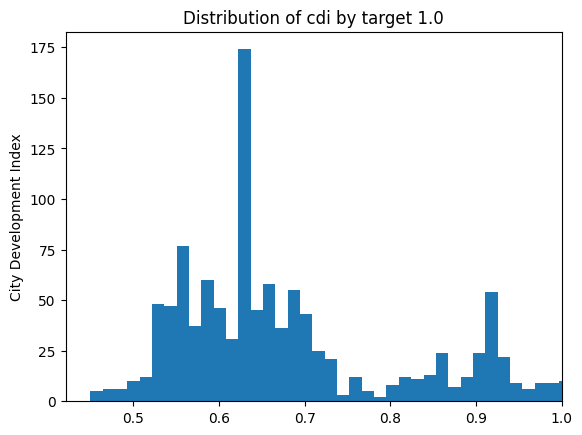

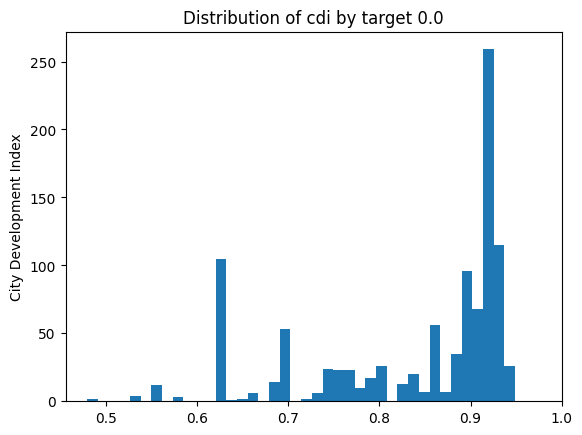

In [ ]:
plt.hist(data["city development index"][data["target"] == 1.0], bins=40)
plt.title("Distribution of cdi by target 1.0")
plt.ylabel("City Development Index")
plt.xlim(right=1.0)
plt.show()

plt.hist(data["city development index"][data["target"] == 0.0], bins=40)
plt.title("Distribution of cdi by target 0.0")
plt.ylabel("City Development Index")
plt.xlim(right=1.0)
plt.show()

#distribution of cdi of target 0.0 heavily skews left, with much higher average than that of target 1.0

In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split

data = pd.get_dummies(data)
X = data.drop(columns=["target"])

y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# Check for dataset imbalance

print(f"Before oversampling: {X_train.shape} \n {np.unique(y_train, return_counts=True)}")

# Dataset is mostly balanced, no need for oversampling

Before oversampling: (1708, 59) 
 (array([0., 1.]), array([837, 871]))


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

gridsearch_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [1, 3, 4, 5, 6],
    "min_samples_split": [2, 4, 6, 8]
}

dt_model = DecisionTreeClassifier()
gridsearch_dt = GridSearchCV(dt_model, gridsearch_params, cv=10)
gridsearch_dt.fit(X_train, y_train)

print(gridsearch_dt.best_params_, gridsearch_dt.best_score_)

#CV for decision tree

{'criterion': 'gini', 'max_depth': 6, 'min_samples_split': 2} 0.8331062951496386


In [ ]:
gridsearch_rf = GridSearchCV(RandomForestClassifier(n_estimators=10, n_jobs=-1), gridsearch_params, cv=10)
gridsearch_rf.fit(X_train, y_train)

#CV results for random forest


,estimator,"RandomForestC...10, n_jobs=-1)"
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [1, 3, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,10


In [128]:
print(gridsearch_rf.best_params_, gridsearch_rf.best_score_)

{'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 4} 0.8319539043687649


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

rf_model = gridsearch_rf.best_estimator_
rf_model.fit(X_train, y_train)
predicted_labels_rf = rf_model.predict(X_test)

print(classification_report(y_test, predicted_labels_rf))

              precision    recall  f1-score   support

         0.0       0.80      0.82      0.81       198
         1.0       0.84      0.82      0.83       229

    accuracy                           0.82       427
   macro avg       0.82      0.82      0.82       427
weighted avg       0.82      0.82      0.82       427



city development index    0.532944
experience                0.142731
enrolled university       0.076566
company size              0.055816
company type              0.052298
last new job              0.043965
training hours            0.041423
education level           0.018930
major discipline          0.018599
relevent experience       0.013804
gender                    0.002925
dtype: float64


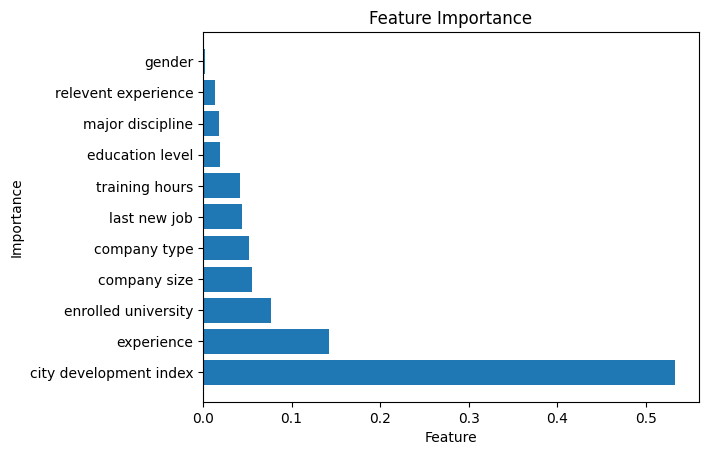

In [ ]:
# Analyzing feature importance
importance = rf_model.feature_importances_
cols = X.columns

feature_importances = pd.Series(importance, index=cols).sort_values(ascending=False)

base_features = feature_importances.index.to_series().str.split("_").str[0]
feature_importances = feature_importances.groupby(base_features).sum().sort_values(ascending=False)

print(feature_importances)

plt.barh(feature_importances.index, feature_importances.values)
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()

''' 
According to my EDA, some features I initially believed to be important for prediction are years of experience, company size, enrolled university, and city development index.
The feature importance analysis comfirmed my belief. However I had not expected cdi to be much more important than the rest
'''

              precision    recall  f1-score   support

         0.0       0.81      0.86      0.83       198
         1.0       0.87      0.83      0.85       229

    accuracy                           0.84       427
   macro avg       0.84      0.84      0.84       427
weighted avg       0.84      0.84      0.84       427



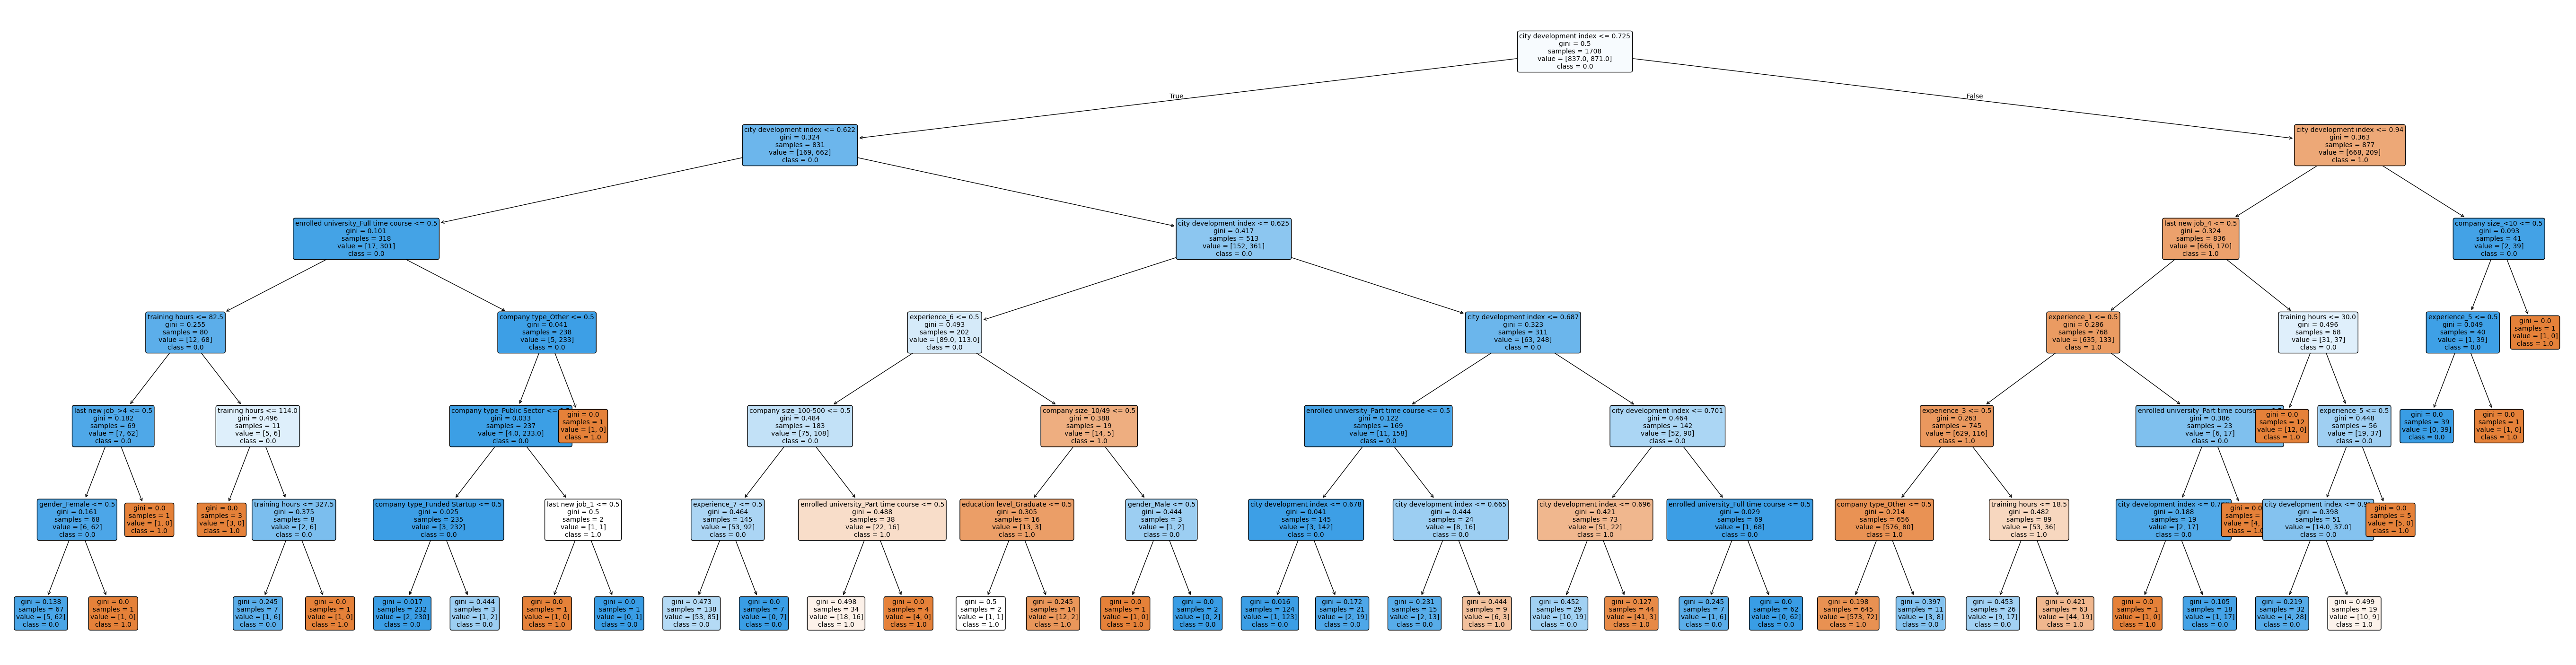

In [ ]:
from sklearn.tree import plot_tree
dt_model = gridsearch_dt.best_estimator_
dt_model.fit(X_train, y_train)
predicted_labels_dt = dt_model.predict(X_test)

print(classification_report(y_test, predicted_labels_dt))

plt.figure(figsize=(70, 18))
plot_tree(dt_model, 
          feature_names=X.columns, 
          class_names=[str(c) for c in y.unique()],  # Convert to strings
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

''' 
Some observations:
- city development index is the feature with the most splits/nodes
- this is followed by (not in order): education level, enrolled university
- many leaf nodes with very few samples (below 5), which could indicate overfitting, could control by tuning min_samples_leaf hyperparameter
'''